In [17]:
import pandas as pd
import numpy as np

# column names
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

# load train data
train_df = pd.read_csv(
    '../CMAPSSData/train_FD001.txt',
    sep=' ',
    header=None
)

# drop extra empty columns (important)
train_df = train_df.dropna(axis=1)

# assign column names
train_df.columns = columns

# show basic info
print("Shape:", train_df.shape)
train_df.head()

Shape: (20631, 26)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [18]:
# Step 1: get max cycle per engine
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

# Step 2: merge with original data
train_df = train_df.merge(max_cycle, on='engine_id', how='left')

# Step 3: compute RUL
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Step 4: drop max_cycle (not needed anymore)
train_df = train_df.drop(columns=['max_cycle'])

# show result
train_df[['engine_id', 'cycle', 'RUL']].head(10)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [19]:
train_df[train_df['engine_id'] == 1][['cycle', 'RUL']].tail()

,cycle,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


0–125 → meaningful learning zone
>125 → treated same (healthy state)

In [20]:
# clip RUL at 125
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# check
train_df[['RUL']].describe()

,RUL
count,20631.000000
mean,86.829286
std,41.673699
min,0.000000
25%,51.000000
50%,103.000000
75%,125.000000
max,125.000000


verifying....

In [21]:
train_df['RUL'].max()

np.int64(125)

checking for constant and useless features

In [22]:
# variance of all columns
var_df = train_df.var().sort_values()

var_df

sensor_1        0.000000e+00
op_setting_3    0.000000e+00
sensor_10       0.000000e+00
sensor_18       0.000000e+00
sensor_19       0.000000e+00
sensor_16       1.926023e-34
sensor_5        3.155597e-30
op_setting_2    8.588541e-08
sensor_6        1.929279e-06
op_setting_1    4.784340e-06
sensor_15       1.406628e-03
sensor_8        5.038938e-03
sensor_13       5.172330e-03
sensor_21       1.171825e-02
sensor_20       3.266927e-02
sensor_11       7.133568e-02
sensor_2        2.500533e-01
sensor_12       5.439850e-01
sensor_7        7.833883e-01
sensor_17       2.398667e+00
sensor_3        3.759099e+01
sensor_4        8.101089e+01
sensor_14       3.639005e+02
sensor_9        4.876536e+02
engine_id       8.542545e+02
RUL             1.736697e+03
cycle           4.744591e+03
dtype: float64

now ckecking forrelation of features with RUL 
if high +ve corr then inc with health 
if high -ve corr then degrades with failure

In [23]:
corr = train_df.corr()['RUL'].sort_values(ascending=False)

corr

RUL             1.000000
sensor_12       0.748870
sensor_7        0.733021
sensor_21       0.707334
sensor_20       0.704626
engine_id       0.031546
op_setting_1   -0.005556
op_setting_2   -0.007091
sensor_6       -0.108289
sensor_14      -0.369753
sensor_9       -0.462151
sensor_13      -0.624034
sensor_8       -0.624568
sensor_3       -0.655030
sensor_2       -0.678458
sensor_17      -0.680829
sensor_15      -0.720858
cycle          -0.746939
sensor_4       -0.757157
sensor_11      -0.775230
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: RUL, dtype: float64

<Axes: xlabel='cycle'>

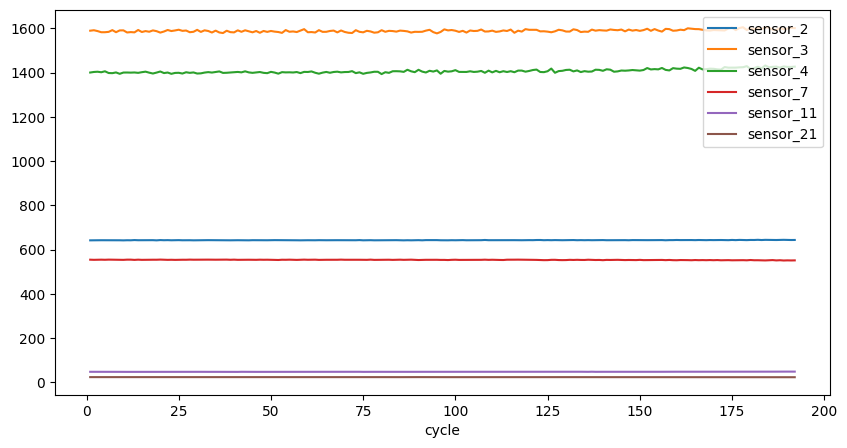

In [24]:
engine_1 = train_df[train_df['engine_id'] == 1]

engine_1.plot(
    x='cycle',
    y=['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_21'],
    figsize=(10,5)
)

sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19, op_setting_3
these all features are useless as they have no variation, no reationship with RUL and are basically noise 

op_setting_1, op_setting_2, sensor_6 (these ones are also very low variance and low correlation)

therefore dropping these features

In [25]:
drop_cols = [
    'sensor_1', 'sensor_5', 'sensor_10',
    'sensor_16', 'sensor_18', 'sensor_19',
    'op_setting_3'
]

train_df = train_df.drop(columns=drop_cols)

train_df.shape

(20631, 20)

Now scaling the full dataset

now dropping sensore 6 as it is constant for all

In [26]:
train_df = train_df.drop(columns=['sensor_6'])


In [27]:
train_df.shape

(20631, 19)

In [28]:
import os

os.makedirs('../data/processed', exist_ok=True)

train_df.to_csv('../data/processed/train_processed.csv', index=False)